In [1]:
import pandas as pd 
df = pd.read_csv('retail_sales_dataset.csv') 
df.head ()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
df.shape

(1000, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
df['Gender'].value_counts()

Female    510
Male      490
Name: Gender, dtype: int64

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

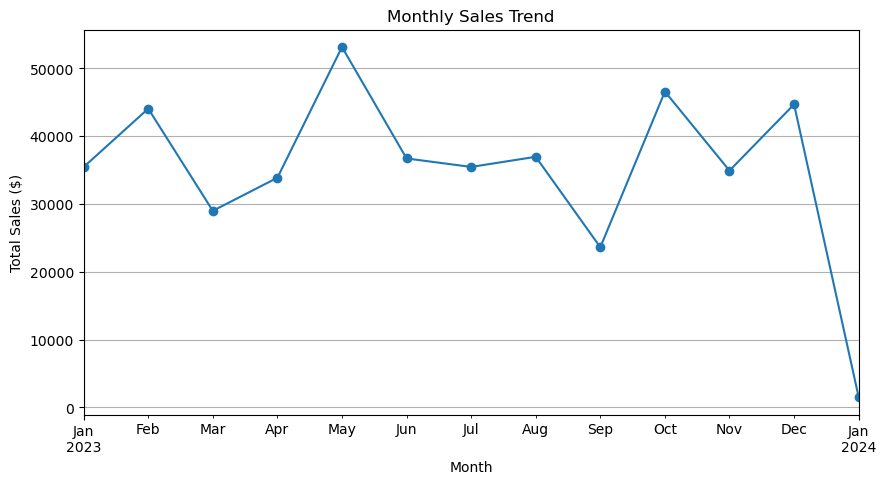

In [8]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.show()


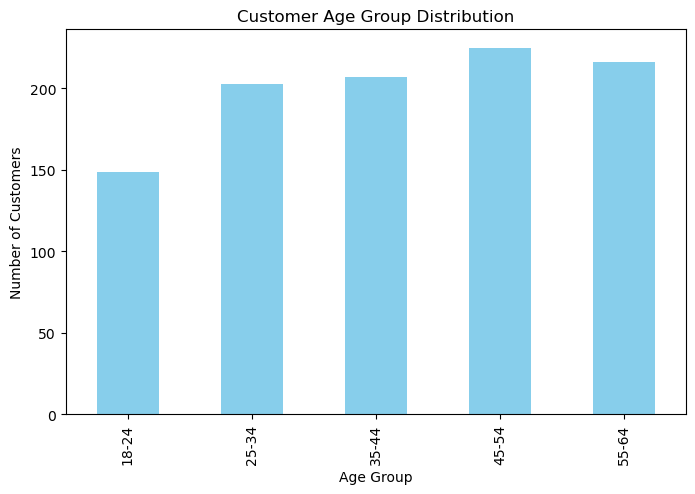

In [9]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

df['Age Group'].value_counts().sort_index().plot(kind='bar', figsize=(8,5), color='skyblue')
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

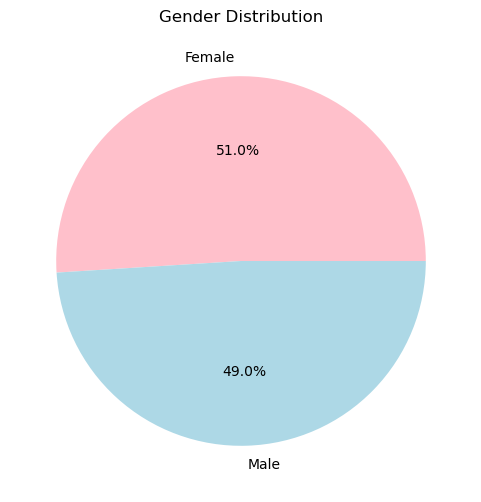

In [10]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), colors=['pink','lightblue'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

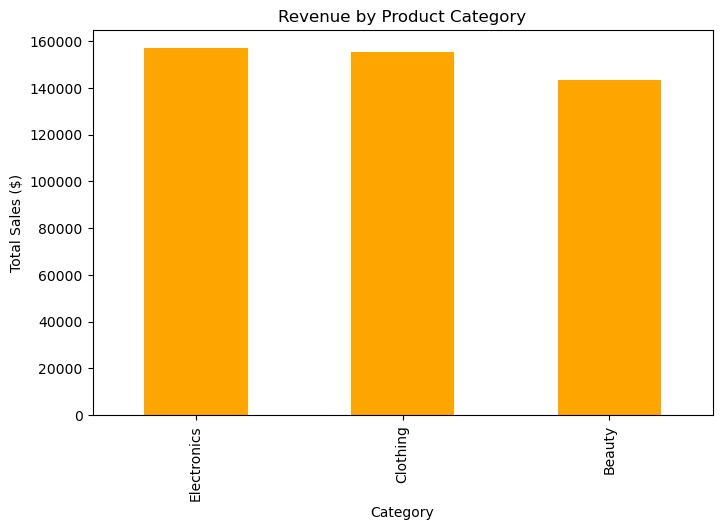

In [11]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar', figsize=(8,5), color='orange')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.show()

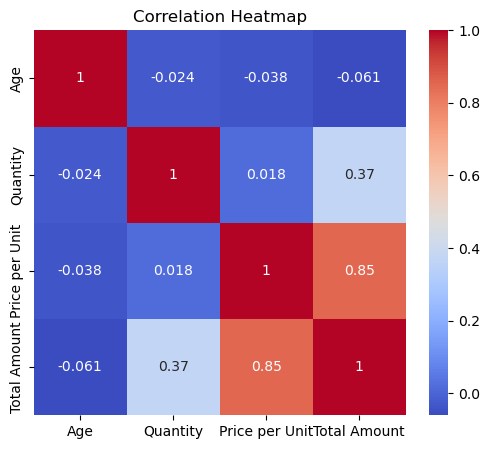

In [12]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df[['Age','Quantity','Price per Unit','Total Amount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

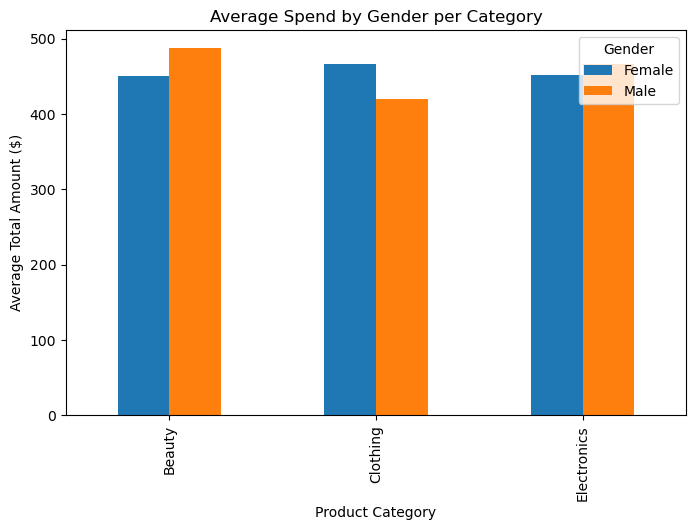

In [13]:
pivot = df.pivot_table(values='Total Amount', index='Product Category', columns='Gender', aggfunc='mean')
pivot.plot(kind='bar', figsize=(8,5))
plt.title('Average Spend by Gender per Category')
plt.ylabel('Average Total Amount ($)')
plt.show()

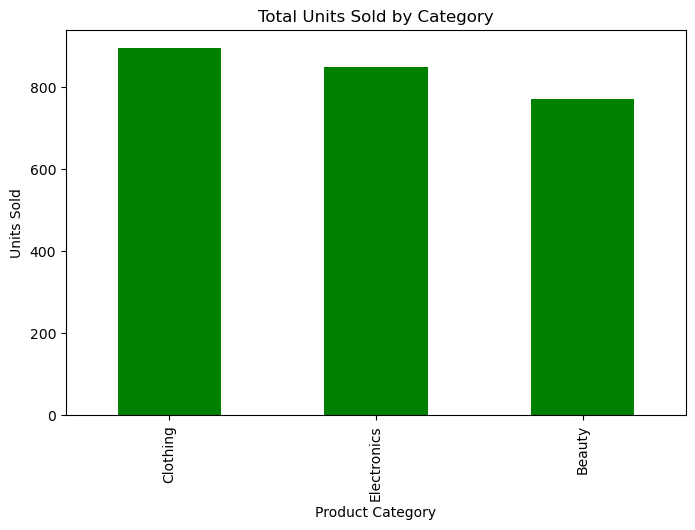

In [14]:
df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(8,5), color='green')
plt.title('Total Units Sold by Category')
plt.ylabel('Units Sold')
plt.show()


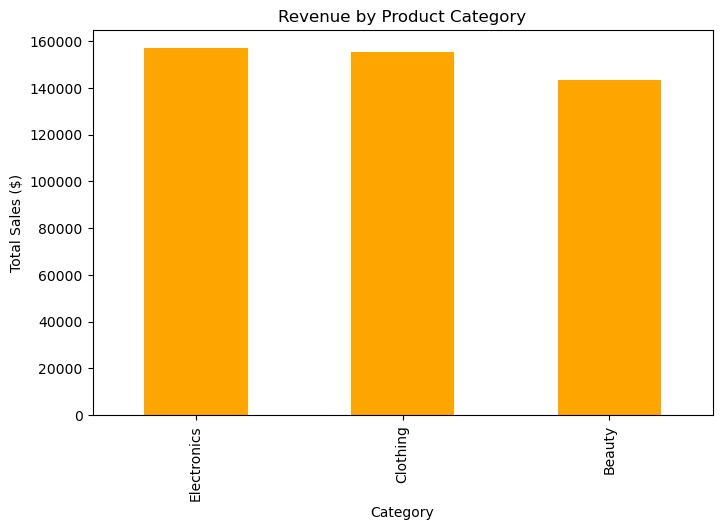

In [15]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar', figsize=(8,5), color='orange')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.show()


In [16]:
category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64